In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/raw/SpotifyFeatures.csv")

# Preview
df.head()



,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [4]:

df.shape


(232725, 18)

In [5]:
df.columns


Index(['genre', 'artist_name', 'track_name', 'track_id', 'popularity',
       'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'time_signature', 'valence'],
      dtype='object')

In [6]:
df['genre'] = (df['genre']
               .str.replace("’", "'", regex=False)
               .str.strip())
df['genre'].nunique(), sorted(df['genre'].unique())[:10]


(26,
 ['A Capella',
  'Alternative',
  'Anime',
  'Blues',
  "Children's Music",
  'Classical',
  'Comedy',
  'Country',
  'Dance',
  'Electronic'])

In [7]:
df['track_id'].nunique()

176774

In [8]:
df['genre'].nunique()

26

In [9]:
df[['track_id','genre']].drop_duplicates().shape 

(232725, 2)

In [11]:
(df.groupby('track_id')['genre'].nunique() > 1).mean()  # % multi-genre tracks


0.1986943781325308

In [12]:
df.groupby('track_id')['genre'].nunique().value_counts().head(10)

genre
1    141650
2     21871
3      8091
4      3374
5      1300
6       358
7       124
8         6
Name: count, dtype: int64

In [13]:
genre_counts = df['genre'].value_counts()
genre_counts.sort_values()


genre
A Capella             119
Movie                7806
Opera                8280
Country              8664
Dance                8701
Reggae               8771
Ska                  8874
Reggaeton            8927
Anime                8936
R&B                  8992
Blues                9023
Soul                 9089
World                9096
Rap                  9232
Classical            9256
Alternative          9263
Rock                 9272
Hip-Hop              9295
Folk                 9299
Electronic           9377
Pop                  9386
Jazz                 9441
Indie                9543
Soundtrack           9646
Comedy               9681
Children's Music    14756
Name: count, dtype: int64

In [16]:
df = df[df['genre'] != 'A Capella'].copy()
df['genre'].nunique()


25

In [17]:
df['pop_pct_genre'] = df.groupby('genre')['popularity'].rank(pct=True, method='average')

thr = 0.20  # start here
df['low_performance'] = (df['pop_pct_genre'] <= thr).astype(int)

df['low_performance'].value_counts(normalize=True)
df.groupby('genre')['low_performance'].mean().sort_values(ascending=False).head(10)



genre
Movie          0.222009
Folk           0.221852
Alternative    0.220987
Dance          0.217446
Electronic     0.213928
Hip-Hop        0.210436
Ska            0.209150
Blues          0.207802
Jazz           0.206652
Country        0.205910
Name: low_performance, dtype: float64

In [19]:
# Final target
df['high_skip_risk_proxy'] = (df['pop_pct_genre'] <= 0.25).astype(int)

# Quick sanity check
df['high_skip_risk_proxy'].value_counts(normalize=True)

high_skip_risk_proxy
0    0.750256
1    0.249744
Name: proportion, dtype: float64

In [20]:
multi_tracks = (
    df.groupby('track_id')['genre']
      .nunique()
      .loc[lambda x: x > 1]
      .index
)

df[df['track_id'].isin(multi_tracks)] \
  .groupby('track_id')['high_skip_risk_proxy'] \
  .nunique() \
  .value_counts(normalize=True)


high_skip_risk_proxy
1    0.726312
2    0.273688
Name: proportion, dtype: float64

In [21]:
numeric_cols = [
    'acousticness','danceability','energy','loudness','tempo',
    'speechiness','instrumentalness','liveness','valence','duration_ms'
]


In [22]:
corr = df[numeric_cols].corr(method='pearson')


Text(0.5, 1.0, 'Correlation Matrix of Audio Features')

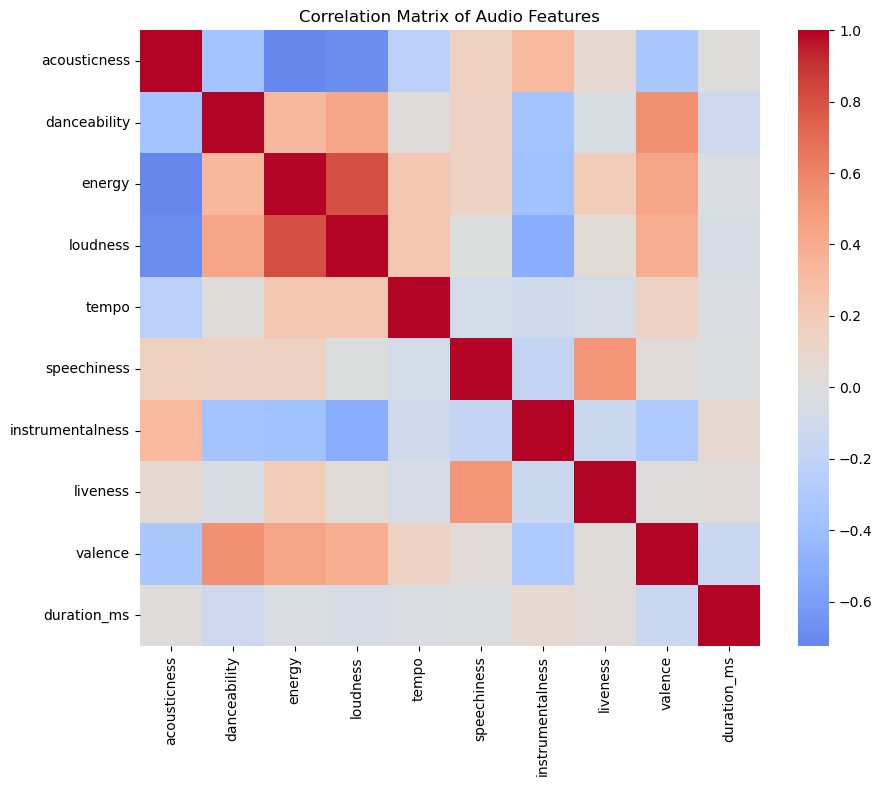

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Audio Features')